<div align="center">

# <span style="color:#2C3E50;">Urban Flood Mapping Using Satellite SAR Data</span>
## <span style="color:#34495E;">Local-Global Mass Conservation Graph Neural Network</span>

</div>

This notebook implements **Approach 8: Local-Global Mass Conservation GNN** — a hybrid CNN-GNN architecture that reformulates SAR flood mapping as a problem of **node classification on a spatially-aware graph**, enforcing the inviolable laws of fluid dynamics through a **mass-conservation physics constraint**.

The motivation: traditional pixel-wise segmentation networks treat each pixel independently and routinely produce **isolated, floating flood predictions** in the middle of high-elevation urban centers — false positives caused almost exclusively by **radar shadow occlusion** behind tall buildings. These predictions violate basic hydrology: real urban floodwater must be *spatially continuous* and topologically *connected* to adjacent open-water sources or known drainage networks.

### Architecture in three stages

1. **CNN Encoder** — extracts dense per-pixel features that suppress speckle noise.
2. **Superpixel Graph Construction** — the input is partitioned into ~300 SLIC superpixels per image, each becoming a single node. Edges connect spatially adjacent superpixels. The CNN feature map is mean-pooled into node embeddings.
3. **Graph Attention Message Passing** — pure-PyTorch GAT-style layers propagate information along the graph, letting nodes aggregate context from their hydrological neighbourhood. Node logits are unpooled back to the pixel grid for dense classification.

### Mass conservation loss

$$L_{total} = L_{WCE} + \mu \cdot L_{mass}$$

$L_{mass}$ runs **K differentiable flood-propagation rounds** at training time: a connectivity score is seeded at every Flooded-Open (class 1) pixel and iteratively diffused through 3×3 neighbourhoods, gated by the network's flood-probability map. Any pixel the model predicts as flooded but whose connectivity score remains near zero is *floating* — physically forbidden, and severely penalised.

The three target classes are:
- **Non-Flooded** (background)
- **Flooded Open** (flood water in open areas — the hydrological *source*)
- **Flooded Urban** (flood water in urban zones — must be connected to a source)

<div align="center">

## <span style="color:#16A085;">Project Information</span>

</div>

| **Field**          | **Details**                                    |
|--------------------|------------------------------------------------|
| **Course**         | Deep Learning Project                          |
| **Deliverable**    | <span style="color:#E67E22;">**Deliverable 3 – Model Training & Evaluation**</span> |
| **Authors**        | Muhammad Sharjeel Nawaz & Syed Moiz Ejaz       |
| **Roll Numbers**   | 28100321 & 28100357                            |
| **Approach**       | Approach 8 — Local-Global Mass Conservation GNN |

---

In [1]:
!pip install -q albumentations tifffile tqdm matplotlib rasterio scikit-image

In [2]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import tifffile as tiff
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.segmentation import slic
import warnings
warnings.filterwarnings("ignore")

In [ ]:
device      = "cuda" if torch.cuda.is_available() else "cpu"
batch_size  = 8
num_workers = 4
epochs      = 40
lr          = 1e-3
imgsize     = 256
in_channels = 8
num_classes = 3
path        = "/kaggle/input/datasets/hritik05/urbansarflood-dataset/train_validation"

n_superpixels = 256
slic_compact  = 10.0
gnn_hidden    = 128
gnn_layers    = 3
gnn_heads     = 4

mu_mass        = 0.5
n_propagation  = 8
flood_thresh   = 0.5
exp_scale_mass = 4.0

classes_name = ["Non-Flooded", "Flooded Open", "Flooded Urban"]

print(f"Device          : {device}")
print(f"Dataset         : {path}")
print(f"Superpixels/img : ~{n_superpixels}")
print(f"GNN             : {gnn_layers} layers × {gnn_heads} heads, hidden={gnn_hidden}")
print(f"Mass cons.      : μ={mu_mass}, K={n_propagation}, exp_α={exp_scale_mass}")

Device          : cuda
Dataset         : /kaggle/input/datasets/hritik05/urbansarflood-dataset/train_validation
Superpixels/img : ~256
GNN             : 3 layers × 4 heads, hidden=128
Mass cons.      : μ=0.5, K=8, exp_α=4.0


## <span style="color:#3498DB;">1. Dataset Preparation</span>

The **UrbanSARFloods** dataset is used. The 8 channels are (per the dataset documentation):

| ch | Category   | Polarisation | Timing      |
|----|------------|--------------|-------------|
|  0 | Coherence  | VH           | Pre-Flood   |
|  1 | Coherence  | VV           | Pre-Flood   |
|  2 | Coherence  | VH           | Post-Flood  |
|  3 | Coherence  | VV           | Post-Flood  |
|  4 | Intensity  | VH           | Pre-Flood   |
|  5 | Intensity  | VV           | Pre-Flood   |
|  6 | Intensity  | VH           | Post-Flood  |
|  7 | Intensity  | VV           | Post-Flood  |

### Key steps in UrbanSARDataset:

- Reads `.tif` files using `rasterio`.
- Extracts SAR image (8 bands) and mask (single band).
- Applies **per-channel min-max normalization**.
- Implements **class balancing** by repeating minority class samples (`03_FU` – Flooded Urban) 4× to counter severe class imbalance.

In [4]:
class UrbanSARDataset(Dataset):
    def __init__(self, dataset_root, split_file, transform=None):
        self.transform   = transform
        self.image_paths = []
        self.mask_paths  = []
        split_path = os.path.join(dataset_root, split_file)
        if os.path.exists(split_path):
            with open(split_path, "r") as f:
                for line in f.readlines():
                    raw_path = line.strip()
                    if not raw_path:
                        continue
                    path_parts    = raw_path.split('/')
                    clean_base    = os.path.join(*path_parts[-3:])
                    if "GT" in clean_base:
                        clean_gt  = clean_base
                        clean_sar = clean_base.replace("GT", "SAR")
                    else:
                        clean_sar = clean_base
                        clean_gt  = clean_base.replace("SAR", "GT")
                    sar_full = os.path.join(dataset_root, clean_sar)
                    gt_full  = os.path.join(dataset_root, clean_gt)
                    repeats  = 4 if ("Train" in split_file and "03_FU" in clean_base) else 1
                    for _ in range(repeats):
                        self.image_paths.append(sar_full)
                        self.mask_paths.append(gt_full)
        else:
            raise FileNotFoundError(f"Split file not found: {split_path}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        with rasterio.open(self.image_paths[index]) as src:
            image = src.read().astype(np.float32)
        with rasterio.open(self.mask_paths[index]) as src:
            mask  = src.read(1).astype(np.int64)
        mask[mask < 0]            = 0
        mask[mask >= num_classes] = 0
        image = np.transpose(image, (1, 2, 0))
        for c in range(in_channels):
            c_min, c_max = image[:, :, c].min(), image[:, :, c].max()
            image[:, :, c] = (image[:, :, c] - c_min) / (c_max - c_min) if c_max > c_min else 0.0
        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask  = aug["mask"]
        image = torch.from_numpy(np.transpose(image, (2, 0, 1)).copy()).float()
        mask  = torch.from_numpy(np.array(mask).copy()).long()
        return image, mask

In [5]:
train_transform = A.Compose([
    A.RandomCrop(height=imgsize, width=imgsize),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
])

val_transform = A.Compose([
    A.CenterCrop(height=imgsize, width=imgsize),
])

try:
    train_dataset = UrbanSARDataset(path, "Train_dataset.txt", transform=train_transform)
    val_dataset   = UrbanSARDataset(path, "Valid_dataset.txt", transform=val_transform)
    print(f"Train samples : {len(train_dataset)}")
    print(f"Val   samples : {len(val_dataset)}")
except Exception as e:
    print(f"Dataset not loaded: {e}")
    exit(1)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

Train samples : 5914
Val   samples : 1970


## <span style="color:#3498DB;">2. Model Architecture — MassConsGNN</span>

### Pipeline
```
Input  (B, 8, 256, 256)
  │
  ├─ CNN Encoder (3 stages, double-conv + maxpool) ─ feat (B, 128, 64, 64)
  │
  ├─ SLIC Superpixel Pooling ─ ~256 nodes/image
  │     • each node = mean of CNN features over its superpixel
  │     • edges = spatial 4-adjacency between superpixels
  │
  ├─ GAT × 3 layers ─ graph attention message passing
  │     • each layer: multi-head attention over neighbours + residual
  │
  ├─ Node Classifier ─ per-node logits over 3 classes
  │
  ├─ Unpool to pixel grid (broadcast node logits to constituent pixels)
  │
  └─ Lightweight CNN refinement (fix superpixel boundary artifacts)
        → (B, 3, 256, 256)

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class CNNEncoder(nn.Module):
    def __init__(self, in_ch: int = 8, feat_ch: int = 128):
        super().__init__()
        self.stage1 = DoubleConv(in_ch,        feat_ch // 4)   # 256
        self.pool1  = nn.MaxPool2d(2)
        self.stage2 = DoubleConv(feat_ch // 4, feat_ch // 2)   # 128
        self.pool2  = nn.MaxPool2d(2)
        self.stage3 = DoubleConv(feat_ch // 2, feat_ch)        # 64

    def forward(self, x: torch.Tensor):
        s1 = self.stage1(x)
        s2 = self.stage2(self.pool1(s1))
        s3 = self.stage3(self.pool2(s2))
        return s1, s2, s3

### Superpixel pooling

We compute a SLIC superpixel labelling on a low-cost SAR composite (during-flood VV intensity) per sample on CPU, **detached from the gradient graph**.


In [ ]:
def compute_slic_labels(image_np: np.ndarray, n_segments: int, compactness: float,
                         min_segments: int = 32):
    composite = np.stack([
        image_np[..., 6],
        image_np[..., 7],
        image_np[..., 3],
    ], axis=-1)
    labels = slic(composite, n_segments=n_segments, compactness=compactness,
                  channel_axis=-1, start_label=0, enforce_connectivity=True)
    uniq  = np.unique(labels)
    remap = -np.ones(uniq.max() + 1, dtype=np.int64)
    remap[uniq] = np.arange(uniq.size)
    labels      = remap[labels]

    if uniq.size < min_segments:
        H, W = labels.shape
        n_per_side = int(round(math.sqrt(n_segments)))
        cell_h     = max(1, H // n_per_side)
        cell_w     = max(1, W // n_per_side)
        ii, jj     = np.meshgrid(np.arange(H) // cell_h, np.arange(W) // cell_w, indexing='ij')
        labels     = (ii * n_per_side + jj).astype(np.int64)
        uniq  = np.unique(labels)
        remap = -np.ones(uniq.max() + 1, dtype=np.int64)
        remap[uniq] = np.arange(uniq.size)
        labels      = remap[labels]
    return labels


def build_adjacency(labels: np.ndarray):
    h_diff = labels[:-1, :] != labels[1:, :]
    w_diff = labels[:, :-1] != labels[:, 1:]

    h_pairs = np.stack([labels[:-1, :][h_diff], labels[1:, :][h_diff]], axis=1)
    w_pairs = np.stack([labels[:, :-1][w_diff], labels[:, 1:][w_diff]], axis=1)
    pairs   = np.concatenate([h_pairs, w_pairs], axis=0)
    pairs = np.sort(pairs, axis=1)
    pairs = np.unique(pairs, axis=0)

    rev      = pairs[:, [1, 0]]
    n_nodes  = int(labels.max() + 1)
    selfloop = np.stack([np.arange(n_nodes)] * 2, axis=1)
    edges    = np.concatenate([pairs, rev, selfloop], axis=0)
    return edges 


def superpixel_pool(features: torch.Tensor, labels: torch.Tensor, n_nodes: int):
    C, H, W = features.shape
    flat_f  = features.reshape(C, -1).t()
    flat_l  = labels.reshape(-1)

    out  = torch.zeros(n_nodes, C, device=features.device, dtype=features.dtype)
    cnt  = torch.zeros(n_nodes, 1, device=features.device, dtype=features.dtype)
    out.index_add_(0, flat_l, flat_f)
    cnt.index_add_(0, flat_l, torch.ones_like(flat_l, dtype=features.dtype).unsqueeze(1))
    return out / cnt.clamp(min=1.0)


def superpixel_unpool(node_logits: torch.Tensor, labels: torch.Tensor):
    return node_logits[labels].permute(2, 0, 1) 

In [ ]:
class GATLayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, n_heads: int = 4, dropout: float = 0.1):
        super().__init__()
        assert out_dim % n_heads == 0, "out_dim must be divisible by n_heads"
        self.n_heads = n_heads
        self.d_head  = out_dim // n_heads

        self.W       = nn.Linear(in_dim,  out_dim, bias=False)
        self.a_src   = nn.Parameter(torch.empty(n_heads, self.d_head))
        self.a_dst   = nn.Parameter(torch.empty(n_heads, self.d_head))
        nn.init.xavier_uniform_(self.a_src)
        nn.init.xavier_uniform_(self.a_dst)

        self.leaky   = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(dropout)
        self.res     = nn.Linear(in_dim, out_dim, bias=False) if in_dim != out_dim else nn.Identity()

    def forward(self, h: torch.Tensor, edges: torch.Tensor) -> torch.Tensor:
        in_dtype = h.dtype

        N   = h32.shape[0]
        Wh  = self.W(h32).view(N, self.n_heads, self.d_head)
        src, dst = edges[:, 0], edges[:, 1]
        e_src = (Wh[src] * self.a_src.float()).sum(dim=-1) 
        e_dst = (Wh[dst] * self.a_dst.float()).sum(dim=-1) 
        e     = self.leaky(e_src + e_dst)

        e_max = torch.full((N, self.n_heads), float('-inf'),
                            device=h.device, dtype=torch.float32)
        e_max = e_max.scatter_reduce(0, dst.unsqueeze(1).expand(-1, self.n_heads),
                                      e, reduce='amax', include_self=True)
        e_max = torch.where(torch.isfinite(e_max), e_max, torch.zeros_like(e_max))
        e     = torch.exp((e - e_max[dst]).clamp(min=-30.0, max=30.0)) 
        e_sum = torch.zeros(N, self.n_heads, device=h.device, dtype=torch.float32)
        e_sum.index_add_(0, dst, e)
        alpha = e / e_sum[dst].clamp(min=1e-12)
        alpha = self.dropout(alpha)

        msg = Wh[src] * alpha.unsqueeze(-1) 
        out = torch.zeros(N, self.n_heads, self.d_head,
                          device=h.device, dtype=torch.float32)
        out.index_add_(0, dst, msg)
        out = out.reshape(N, self.n_heads * self.d_head)
        residual = self.res(h32)
        result   = F.elu(out + residual)
        return result.to(in_dtype)

In [ ]:
class MassConsGNN(nn.Module):
    def __init__(
        self,
        in_channels:   int = 8,
        num_classes:   int = 3,
        feat_ch:       int = 128,
        gnn_hidden:    int = 128,
        gnn_layers:    int = 3,
        gnn_heads:     int = 4,
    ):
        super().__init__()
        self.encoder = CNNEncoder(in_channels, feat_ch)
        layers = []
        in_dim = feat_ch
        for _ in range(gnn_layers):
            layers.append(GATLayer(in_dim, gnn_hidden, n_heads=gnn_heads))
            in_dim = gnn_hidden
        self.gnn = nn.ModuleList(layers)

        self.node_classifier = nn.Linear(gnn_hidden, num_classes)

        self.up1 = nn.ConvTranspose2d(num_classes,    feat_ch // 4, 2, stride=2) 
        self.up2 = nn.ConvTranspose2d(feat_ch // 4,   feat_ch // 4, 2, stride=2)
        self.refine = DoubleConv(feat_ch // 4 + feat_ch // 4, feat_ch // 4)
        self.out_conv = nn.Conv2d(feat_ch // 4, num_classes, 1)

    def forward(
        self,
        x: torch.Tensor,
        labels_lr: list,
        edges: list, 
    ) -> torch.Tensor:
        s1, s2, s3 = self.encoder(x) 
        B, C, Hq, Wq = s3.shape

        coarse_logits = []
        for b in range(B):
            lab_b   = labels_lr[b].to(x.device) 
            edg_b   = edges[b].to(x.device)    
            n_nodes = int(lab_b.max().item()) + 1

            node_h  = superpixel_pool(s3[b], lab_b, n_nodes)
            for layer in self.gnn:
                node_h = layer(node_h, edg_b)
            node_l  = self.node_classifier(node_h) 

            pix_l   = superpixel_unpool(node_l, lab_b)  
            coarse_logits.append(pix_l)
        coarse_logits = torch.stack(coarse_logits, dim=0)  

        u = self.up1(coarse_logits) 
        u = self.up2(u)  
        u = self.refine(torch.cat([u, s1], dim=1)) 
        return self.out_conv(u) 

In [ ]:
@torch.no_grad()
def build_graph_inputs(images: torch.Tensor, n_segments: int, compactness: float, lr_size: int):
    B, C, H, W = images.shape
    images_lr = F.interpolate(images, size=(lr_size, lr_size), mode="bilinear",
                                align_corners=False).cpu().numpy()
    images_lr = np.transpose(images_lr, (0, 2, 3, 1)) 
    labels_list, edges_list = [], []
    for b in range(B):
        lab = compute_slic_labels(images_lr[b], n_segments=n_segments,
                                  compactness=compactness)
        edg = build_adjacency(lab)
        labels_list.append(torch.from_numpy(lab).long())
        edges_list.append(torch.from_numpy(edg).long())
    return labels_list, edges_list

In [ ]:
model = MassConsGNN(
    in_channels = in_channels,
    num_classes = num_classes,
    feat_ch     = 128,
    gnn_hidden  = gnn_hidden,
    gnn_layers  = gnn_layers,
    gnn_heads   = gnn_heads,
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

with torch.no_grad():
    dummy        = torch.rand(2, in_channels, imgsize, imgsize).to(device)
    lr_size      = imgsize // 4
    labels_lr, edges = build_graph_inputs(dummy, n_segments=n_superpixels,
                                          compactness=slic_compact, lr_size=lr_size)
    out = model(dummy, labels_lr, edges)
    print(f"Input  shape : {dummy.shape}")
    print(f"Output shape : {out.shape}  ← expected (2, {num_classes}, {imgsize}, {imgsize})")
    print(f"Avg superpixel count: {np.mean([int(l.max())+1 for l in labels_lr]):.0f}")
    print(f"Avg edge count     : {np.mean([e.shape[0] for e in edges]):.0f}")

Total parameters     : 371,622
Trainable parameters : 371,622
Input  shape : torch.Size([2, 8, 256, 256])
Output shape : torch.Size([2, 3, 256, 256])  ← expected (2, 3, 256, 256)
Avg superpixel count: 256
Avg edge count     : 1216


## <span style="color:#3498DB;">3. Mass-Conservation Physics Loss</span>

$$L_{total} = L_{WCE} + \mu \cdot L_{mass}$$

### Differentiable flood propagation

$$\phi^{(t)}(i,j) = g(i,j) \cdot \max\!\Big( \phi^{(t-1)}(i,j),\ \big[\mathrm{MaxPool}_{3\times 3}\, \phi^{(t-1)}\big](i,j) \Big)$$


### Penalty
$$L_{mass} = \frac{1}{\sum p_{flood}} \sum_{(i,j)} p_{flood}(i,j) \cdot \big( e^{\alpha (1 - \phi(i,j))} - 1 \big)$$


In [ ]:
class MassConservationLoss(nn.Module):

    def __init__(
        self,
        class_weights: torch.Tensor,
        n_propagation: int   = 8,
        flood_thresh:  float = 0.5,
        exp_scale:     float = 4.0,
        mu_mass:       float = 0.5,
    ):
        super().__init__()
        self.wce           = nn.CrossEntropyLoss(weight=class_weights)
        self.K             = n_propagation
        self.flood_thresh  = flood_thresh
        self.exp_scale     = exp_scale
        self.mu_mass       = mu_mass

    @staticmethod
    def _propagate(phi: torch.Tensor, gate: torch.Tensor, K: int) -> torch.Tensor:
        """K rounds of gated 3×3 max-propagation. Operates in fp32 for stability."""
        for _ in range(K):
            neigh = F.max_pool2d(phi.unsqueeze(1), kernel_size=3, stride=1, padding=1).squeeze(1)
            phi   = gate * torch.maximum(phi, neigh)
            phi   = phi.clamp(0.0, 1.0)
        return phi

    def forward(self, logits: torch.Tensor, masks: torch.Tensor):
        l_wce = self.wce(logits.float(), masks)
        prob       = F.softmax(logits.float(), dim=1)
        p_open     = prob[:, 1].clamp(0.0, 1.0)
        p_urban    = prob[:, 2].clamp(0.0, 1.0) 
        p_flood    = (p_open + p_urban).clamp(0.0, 1.0) 

        phi = self._propagate(p_open, gate=p_flood, K=self.K)
        exponent   = (self.exp_scale * (1.0 - phi)).clamp(max=20.0)
        violation  = torch.exp(exponent) - 1.0
        weighted   = p_flood * violation

        weighted   = torch.nan_to_num(weighted, nan=0.0, posinf=0.0, neginf=0.0)
        denom      = p_flood.sum().clamp(min=1.0)
        l_mass     = weighted.sum() / denom

        with torch.no_grad():
            hard_pred_flood   = (p_flood > self.flood_thresh)
            hard_disconnected = (phi    < 0.1) & hard_pred_flood
            floating_frac     = hard_disconnected.float().sum() / hard_pred_flood.float().sum().clamp(min=1.0)

        l_total = l_wce + self.mu_mass * l_mass
        return l_total, l_wce.detach(), l_mass.detach(), phi.detach(), floating_frac.detach()

In [ ]:
_test_loss = MassConservationLoss(
    class_weights=torch.tensor([0.1, 0.4, 0.5]).to(device),
    n_propagation=n_propagation, flood_thresh=flood_thresh,
    exp_scale=exp_scale_mass, mu_mass=mu_mass,
)
_H = 64
_logits = torch.full((1, num_classes, _H, _H), -5.0, device=device)
_logits[:, 0] = 5.0
_logits[:, 0, 10:20, 10:20] = -5.0
_logits[:, 1, 10:20, 10:20] =  5.0  
_logits[:, 0, 18:28, 18:28] = -5.0
_logits[:, 2, 18:28, 18:28] =  5.0 

_logits[:, 0, 45:55, 45:55] = -5.0
_logits[:, 2, 45:55, 45:55] =  5.0 
_masks = torch.zeros(1, _H, _H, dtype=torch.long, device=device)

_, _, _l_mass, _phi, _floating = _test_loss(_logits, _masks)

phi_connected = _phi[0, 18:28, 18:28].mean().item()
phi_floating  = _phi[0, 45:55, 45:55].mean().item()

print(f"φ at connected urban flood : {phi_connected:.3f}   (should be close to 1.0)")
print(f"φ at floating  urban flood : {phi_floating:.3f}   (should be close to 0.0)")
print(f"L_mass (synthetic)         : {_l_mass.item():.4f}")
print(f"Hard-count floating frac   : {_floating.item()*100:.1f}%")

assert phi_connected > 0.5, "φ should propagate through the connected chain"
assert phi_floating  < 0.2, "φ should NOT reach the isolated floating blob"
print("\nMass-conservation field behaves as expected.")
del _test_loss, _logits, _masks, _phi

φ at connected urban flood : 0.980   (should be close to 1.0)
φ at floating  urban flood : 0.000   (should be close to 0.0)
L_mass (synthetic)         : 18.2328
Hard-count floating frac   : 33.8%

Mass-conservation field behaves as expected.


In [14]:
class_weights = torch.tensor([0.1, 0.4, 0.5]).to(device)
loss_fn       = MassConservationLoss(
    class_weights = class_weights,
    n_propagation = n_propagation,
    flood_thresh  = flood_thresh,
    exp_scale     = exp_scale_mass,
    mu_mass       = mu_mass,
)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
scaler    = torch.amp.GradScaler("cuda") if device == "cuda" else None

## <span style="color:#3498DB;">4. Metrics</span>

In [ ]:
def compute_metrics(preds: torch.Tensor, targets: torch.Tensor, nc: int):
    preds   = torch.argmax(preds, dim=1).view(-1)
    targets = targets.view(-1)
    ious, f1s = [], []
    for cls in range(nc):
        pred_m   = preds == cls
        tgt_m    = targets == cls
        inter    = (pred_m & tgt_m).sum().float()
        union    = pred_m.sum() + tgt_m.sum() - inter
        denom_f1 = pred_m.sum() + tgt_m.sum()
        ious.append((inter / union).item() if union > 0 else float('nan'))
        f1s.append(((2.0 * inter) / denom_f1.float()).item() if denom_f1 > 0 else float('nan'))
    return ious, f1s

## <span style="color:#3498DB;">5. Training Loop</span>


In [ ]:
best_val_loss = float('inf')
history = {
    "train_loss": [], "train_wce": [], "train_mass": [],
    "val_loss":   [], "val_wce":   [], "val_mass":   [],
    "miou":       [], "mf1":       [], "urban_f1":   [],
    "floating_frac": [],
}

ckpt_best  = "masscons_gnn_best.pth"
ckpt_final = "masscons_gnn_final.pth"
lr_size    = imgsize // 4  

for epoch in range(epochs):
    model.train()
    train_loss, train_wce, train_mass = 0.0, 0.0, 0.0
    n_skipped = 0
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Train]", leave=False)

    for images, masks in train_loop:
        images, masks = images.to(device), masks.to(device)
        labels_lr, edges = build_graph_inputs(images, n_segments=n_superpixels,
                                              compactness=slic_compact, lr_size=lr_size)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.amp.autocast("cuda"):
                preds                                = model(images, labels_lr, edges)
                loss, l_wce, l_mass, _, _            = loss_fn(preds, masks)
            if not torch.isfinite(loss):
                n_skipped += 1
                optimizer.zero_grad(set_to_none=True)
                continue

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            preds                     = model(images, labels_lr, edges)
            loss, l_wce, l_mass, _, _ = loss_fn(preds, masks)
            if not torch.isfinite(loss):
                n_skipped += 1
                optimizer.zero_grad(set_to_none=True)
                continue
            loss.backward()
            optimizer.step()

        train_loss += loss.item()
        train_wce  += l_wce.item()
        train_mass += l_mass.item()
        train_loop.set_postfix(
            loss=f"{loss.item():.4f}",
            wce=f"{l_wce.item():.4f}",
            mass=f"{l_mass.item():.4f}",
        )

    n_train         = max(1, len(train_loader) - n_skipped)
    avg_train_loss  = train_loss / n_train
    avg_train_wce   = train_wce  / n_train
    avg_train_mass  = train_mass / n_train
    if n_skipped > 0:
        print(f"  [warn] skipped {n_skipped} train batch(es) due to non-finite loss")

    model.eval()
    val_loss, val_wce, val_mass = 0.0, 0.0, 0.0
    val_floating = 0.0
    val_ious, val_f1s = [], []
    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{epochs} [Val]  ", leave=False)

    with torch.no_grad():
        for images, masks in val_loop:
            images, masks = images.to(device), masks.to(device)
            labels_lr, edges = build_graph_inputs(images, n_segments=n_superpixels,
                                                  compactness=slic_compact, lr_size=lr_size)
            if scaler is not None:
                with torch.amp.autocast("cuda"):
                    preds                                       = model(images, labels_lr, edges)
                    loss, l_wce, l_mass, _, floating_frac       = loss_fn(preds, masks)
            else:
                preds                                = model(images, labels_lr, edges)
                loss, l_wce, l_mass, _, floating_frac = loss_fn(preds, masks)
            val_loss     += loss.item()
            val_wce      += l_wce.item()
            val_mass     += l_mass.item()
            val_floating += floating_frac.item()
            b_ious, b_f1s = compute_metrics(preds, masks, num_classes)
            val_ious.append(b_ious)
            val_f1s.append(b_f1s)

    n_val            = len(val_loader)
    avg_val_loss     = val_loss     / n_val
    avg_val_wce      = val_wce      / n_val
    avg_val_mass     = val_mass     / n_val
    avg_val_floating = val_floating / n_val
    epoch_ious       = np.nanmean(np.array(val_ious), axis=0)
    epoch_f1s        = np.nanmean(np.array(val_f1s),  axis=0)
    miou             = np.nanmean(epoch_ious)
    mf1              = np.nanmean(epoch_f1s)
    urban_f1         = epoch_f1s[2]

    scheduler.step()

    history["train_loss"].append(avg_train_loss)
    history["train_wce"].append(avg_train_wce)
    history["train_mass"].append(avg_train_mass)
    history["val_loss"].append(avg_val_loss)
    history["val_wce"].append(avg_val_wce)
    history["val_mass"].append(avg_val_mass)
    history["miou"].append(miou)
    history["mf1"].append(mf1)
    history["urban_f1"].append(urban_f1)
    history["floating_frac"].append(avg_val_floating)

    print(
        f"Epoch {epoch+1:02d}/{epochs} | "
        f"Train: {avg_train_loss:.4f} (WCE {avg_train_wce:.4f} + μ·Mass {avg_train_mass:.4f}) | "
        f"Val: {avg_val_loss:.4f} (WCE {avg_val_wce:.4f} + μ·Mass {avg_val_mass:.4f}) | "
        f"mIoU: {miou:.4f} | mF1: {mf1:.4f} | Urban F1: {urban_f1:.4f} | "
        f"Floating: {avg_val_floating*100:.2f}%"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), ckpt_best)

torch.save(model.state_dict(), ckpt_final)
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

Epoch 01/40 | Train: 2.7999 (WCE 1.8138 + μ·Mass 1.9722) | Val: 2.2783 (WCE 1.7562 + μ·Mass 1.0441) | mIoU: 0.0794 | mF1: 0.1296 | Urban F1: 0.0013 | Floating: 0.00%


Epoch 02/40 | Train: 2.1414 (WCE 1.6344 + μ·Mass 1.0140) | Val: 2.1865 (WCE 1.7236 + μ·Mass 0.9258) | mIoU: 0.1045 | mF1: 0.1630 | Urban F1: 0.0048 | Floating: 0.00%


Epoch 03/40 | Train: 2.1086 (WCE 1.6138 + μ·Mass 0.9896) | Val: 2.1212 (WCE 1.6350 + μ·Mass 0.9725) | mIoU: 0.1080 | mF1: 0.1677 | Urban F1: 0.0076 | Floating: 0.00%


Epoch 04/40 | Train: 2.0952 (WCE 1.6038 + μ·Mass 0.9829) | Val: 2.0898 (WCE 1.5745 + μ·Mass 1.0306) | mIoU: 0.1102 | mF1: 0.1700 | Urban F1: 0.0018 | Floating: 0.00%


Epoch 05/40 | Train: 2.0892 (WCE 1.5989 + μ·Mass 0.9805) | Val: 2.0920 (WCE 1.5852 + μ·Mass 1.0136) | mIoU: 0.1103 | mF1: 0.1701 | Urban F1: 0.0041 | Floating: 0.00%


...

Epoch 36/40 | Train: 2.0567 (WCE 1.5744 + μ·Mass 0.9646) | Val: 2.0679 (WCE 1.5817 + μ·Mass 0.9722) | mIoU: 0.1105 | mF1: 0.1705 | Urban F1: 0.0015 | Floating: 0.00%


Epoch 37/40 | Train: 2.0512 (WCE 1.5699 + μ·Mass 0.9626) | Val: 2.0692 (WCE 1.5886 + μ·Mass 0.9613) | mIoU: 0.1104 | mF1: 0.1703 | Urban F1: 0.0015 | Floating: 0.00%


Epoch 38/40 | Train: 2.0541 (WCE 1.5725 + μ·Mass 0.9631) | Val: 2.0694 (WCE 1.5893 + μ·Mass 0.9603) | mIoU: 0.1107 | mF1: 0.1708 | Urban F1: 0.0011 | Floating: 0.00%


Epoch 39/40 | Train: 2.0540 (WCE 1.5725 + μ·Mass 0.9630) | Val: 2.0683 (WCE 1.5875 + μ·Mass 0.9617) | mIoU: 0.1112 | mF1: 0.1716 | Urban F1: 0.0011 | Floating: 0.00%


Epoch 40/40 | Train: 2.0509 (WCE 1.5698 + μ·Mass 0.9622) | Val: 2.0685 (WCE 1.5885 + μ·Mass 0.9600) | mIoU: 0.1109 | mF1: 0.1711 | Urban F1: 0.0012 | Floating: 0.00%

Training complete. Best val loss: 2.0679


## <span style="color:#3498DB;">6. Training Curves</span>

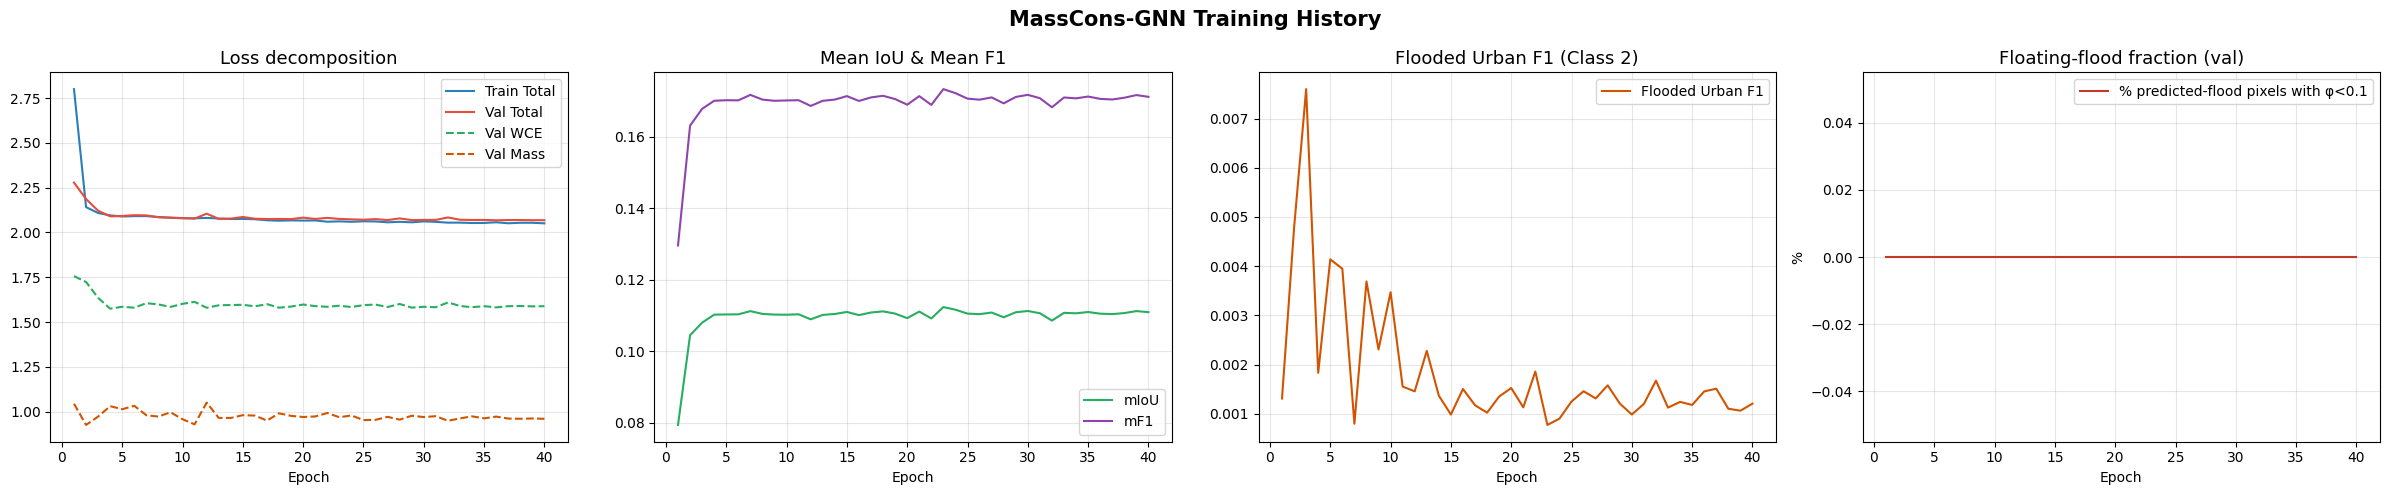

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
ep = range(1, epochs + 1)

axes[0].plot(ep, history["train_loss"], label="Train Total", color="#2980B9")
axes[0].plot(ep, history["val_loss"],   label="Val Total",   color="#E74C3C")
axes[0].plot(ep, history["val_wce"],    label="Val WCE",     color="#27AE60", linestyle="--")
axes[0].plot(ep, history["val_mass"],   label="Val Mass",    color="#D35400", linestyle="--")
axes[0].set_title("Loss decomposition", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history["miou"], label="mIoU", color="#27AE60")
axes[1].plot(ep, history["mf1"],  label="mF1",  color="#8E44AD")
axes[1].set_title("Mean IoU & Mean F1", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(ep, history["urban_f1"], label="Flooded Urban F1", color="#D35400")
axes[2].set_title("Flooded Urban F1 (Class 2)", fontsize=13)
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.3)

axes[3].plot(ep, [f * 100 for f in history["floating_frac"]],
             label="% predicted-flood pixels with φ<0.1", color="#C0392B")
axes[3].set_title("Floating-flood fraction (val)", fontsize=13)
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("%")
axes[3].legend()
axes[3].grid(alpha=0.3)

plt.suptitle("MassCons-GNN Training History", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("masscons_gnn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## <span style="color:#3498DB;">7. Evaluation on Validation Set</span>


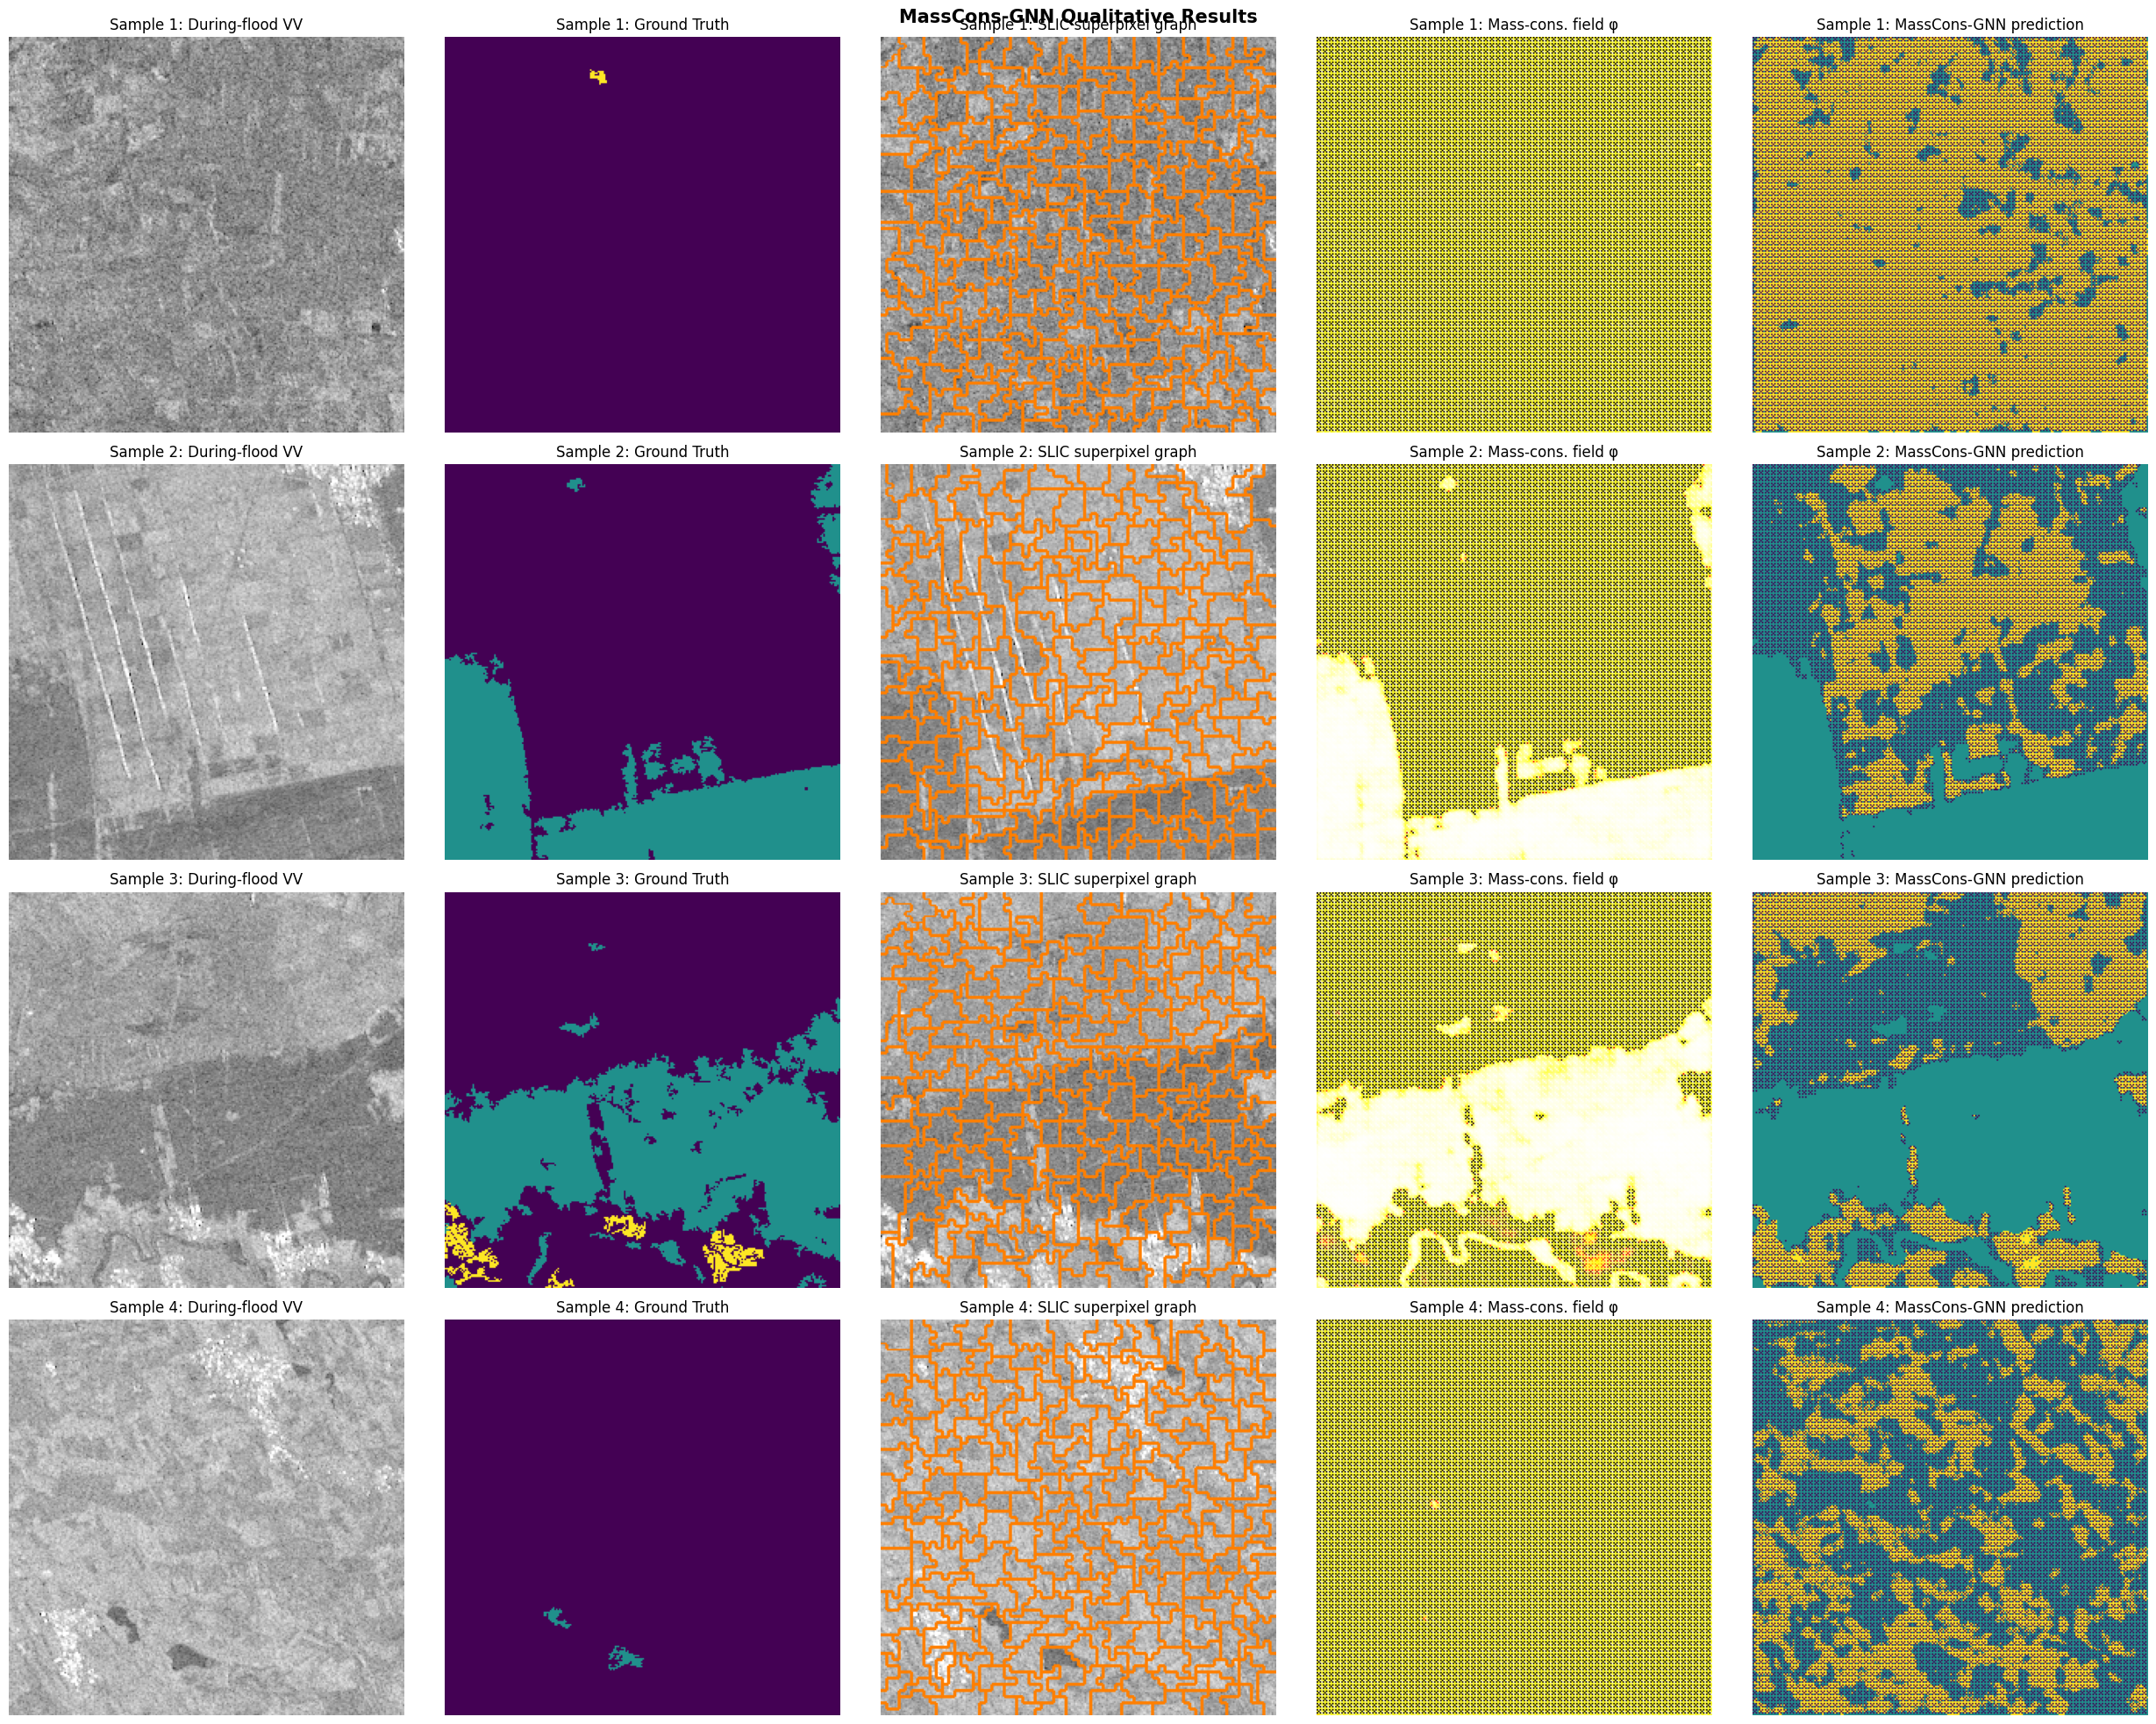

In [ ]:
from skimage.segmentation import mark_boundaries

model.load_state_dict(torch.load(ckpt_best, map_location=device))
model.eval()

val_images, val_masks = next(iter(val_loader))
val_images_dev        = val_images.to(device)
labels_lr_vis, edges_vis = build_graph_inputs(val_images_dev, n_segments=n_superpixels,
                                              compactness=slic_compact, lr_size=lr_size)

with torch.no_grad():
    if scaler is not None:
        with torch.amp.autocast("cuda"):
            raw_preds = model(val_images_dev, labels_lr_vis, edges_vis)
    else:
        raw_preds = model(val_images_dev, labels_lr_vis, edges_vis)
    _, _, _, phi_vis, _ = loss_fn(raw_preds, val_masks.to(device))

pred_masks      = torch.argmax(raw_preds, dim=1).cpu().numpy()
val_images_cpu  = val_images.numpy()
val_masks_cpu   = val_masks.numpy()
phi_cpu         = phi_vis.cpu().numpy()

labels_full = []
for lab_lr in labels_lr_vis:
    lab_full = F.interpolate(lab_lr.float().unsqueeze(0).unsqueeze(0),
                              size=(imgsize, imgsize), mode="nearest").squeeze().long().numpy()
    labels_full.append(lab_full)

num_samples = min(4, batch_size)
fig, axes   = plt.subplots(num_samples, 5, figsize=(25, 5 * num_samples))

for i in range(num_samples):
    sar_vv = val_images_cpu[i, 7]

    axes[i, 0].imshow(sar_vv, cmap="gray")
    axes[i, 0].set_title(f"Sample {i+1}: During-flood VV")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(val_masks_cpu[i], cmap="viridis", vmin=0, vmax=2)
    axes[i, 1].set_title(f"Sample {i+1}: Ground Truth")
    axes[i, 1].axis("off")

    sar_norm = (sar_vv - sar_vv.min()) / (sar_vv.max() - sar_vv.min() + 1e-8)
    bnd      = mark_boundaries(np.stack([sar_norm]*3, axis=-1), labels_full[i], color=(1, 0.5, 0))
    axes[i, 2].imshow(bnd)
    axes[i, 2].set_title(f"Sample {i+1}: SLIC superpixel graph")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(phi_cpu[i], cmap="hot", vmin=0, vmax=1)
    axes[i, 3].set_title(f"Sample {i+1}: Mass-cons. field φ")
    axes[i, 3].axis("off")

    axes[i, 4].imshow(pred_masks[i], cmap="viridis", vmin=0, vmax=2)
    axes[i, 4].set_title(f"Sample {i+1}: MassCons-GNN prediction")
    axes[i, 4].axis("off")

plt.suptitle("MassCons-GNN Qualitative Results", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("masscons_gnn_predictions.png", dpi=150, bbox_inches="tight")
plt.show()